# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [1]:
import numpy as np
import pandas as pd

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [2]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"

colnames = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

#Load the file from local directory using pd.read_csv which is a special form of read_table
#while reading the data, supply the "colnames" list

pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)

In [7]:
pima_df.head(10)

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [5]:
pima_df.sample(n=10, random_state=1)

,preg,plas,pres,skin,test,mass,pedi,age,class
285,7,136,74,26,135,26.0,0.647,51,0
101,1,151,60,0,0,26.1,0.179,22,0
581,6,109,60,27,0,25.0,0.206,27,0
352,3,61,82,28,0,34.4,0.243,46,0
726,1,116,78,29,180,36.1,0.496,25,0
472,0,119,66,27,0,38.8,0.259,22,0
233,4,122,68,0,0,35.0,0.394,29,0
385,1,119,54,13,50,22.3,0.205,24,0
556,1,97,70,40,0,38.1,0.218,30,0
59,0,105,64,41,142,41.5,0.173,22,0


# Q3 Print the datatypes of each column and the shape of the dataset 

In [13]:
pima_df.info()
pima_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
plas     768 non-null int64
pres     768 non-null int64
skin     768 non-null int64
test     768 non-null int64
mass     768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [21]:
pima_df=pima_df.mask(pima_df==0).fillna(pima_df.median())
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null float64
plas     768 non-null float64
pres     768 non-null float64
skin     768 non-null float64
test     768 non-null float64
mass     768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null float64
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


# Q5 Print the descriptive statistics of each & every column using describe() function

In [6]:
pima_df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

C:\Users\OSF\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


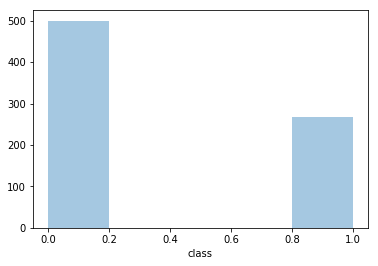

In [23]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.distplot(pima_df['class'],kde = False)
plt.show()

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

C:\Users\OSF\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


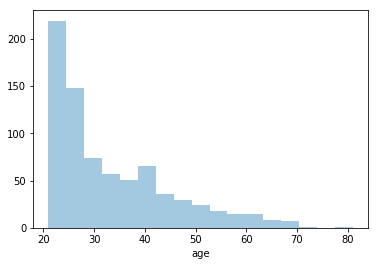

In [24]:
sns.distplot(pima_df['age'],kde = False)
plt.show()

preg        AxesSubplot(0.125,0.657941;0.227941x0.222059)
plas     AxesSubplot(0.398529,0.657941;0.227941x0.222059)
pres     AxesSubplot(0.672059,0.657941;0.227941x0.222059)
skin        AxesSubplot(0.125,0.391471;0.227941x0.222059)
test     AxesSubplot(0.398529,0.391471;0.227941x0.222059)
mass     AxesSubplot(0.672059,0.391471;0.227941x0.222059)
pedi           AxesSubplot(0.125,0.125;0.227941x0.222059)
age         AxesSubplot(0.398529,0.125;0.227941x0.222059)
class       AxesSubplot(0.672059,0.125;0.227941x0.222059)
dtype: object

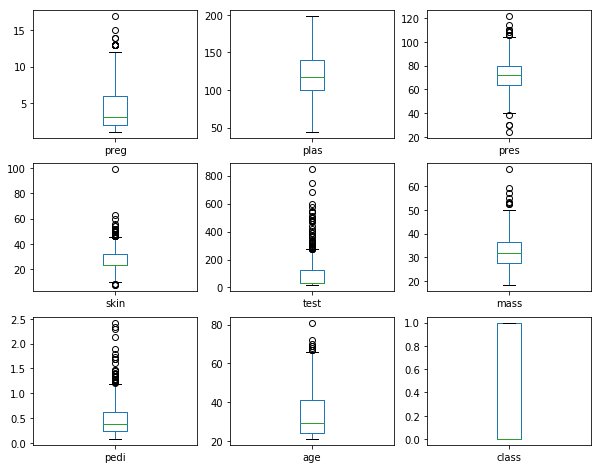

In [77]:
pima_df.plot(kind= 'box' , subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(10,8))

In [ ]:
# Age column is right skewed which means we have more data points to the right side, very far from mean. 

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


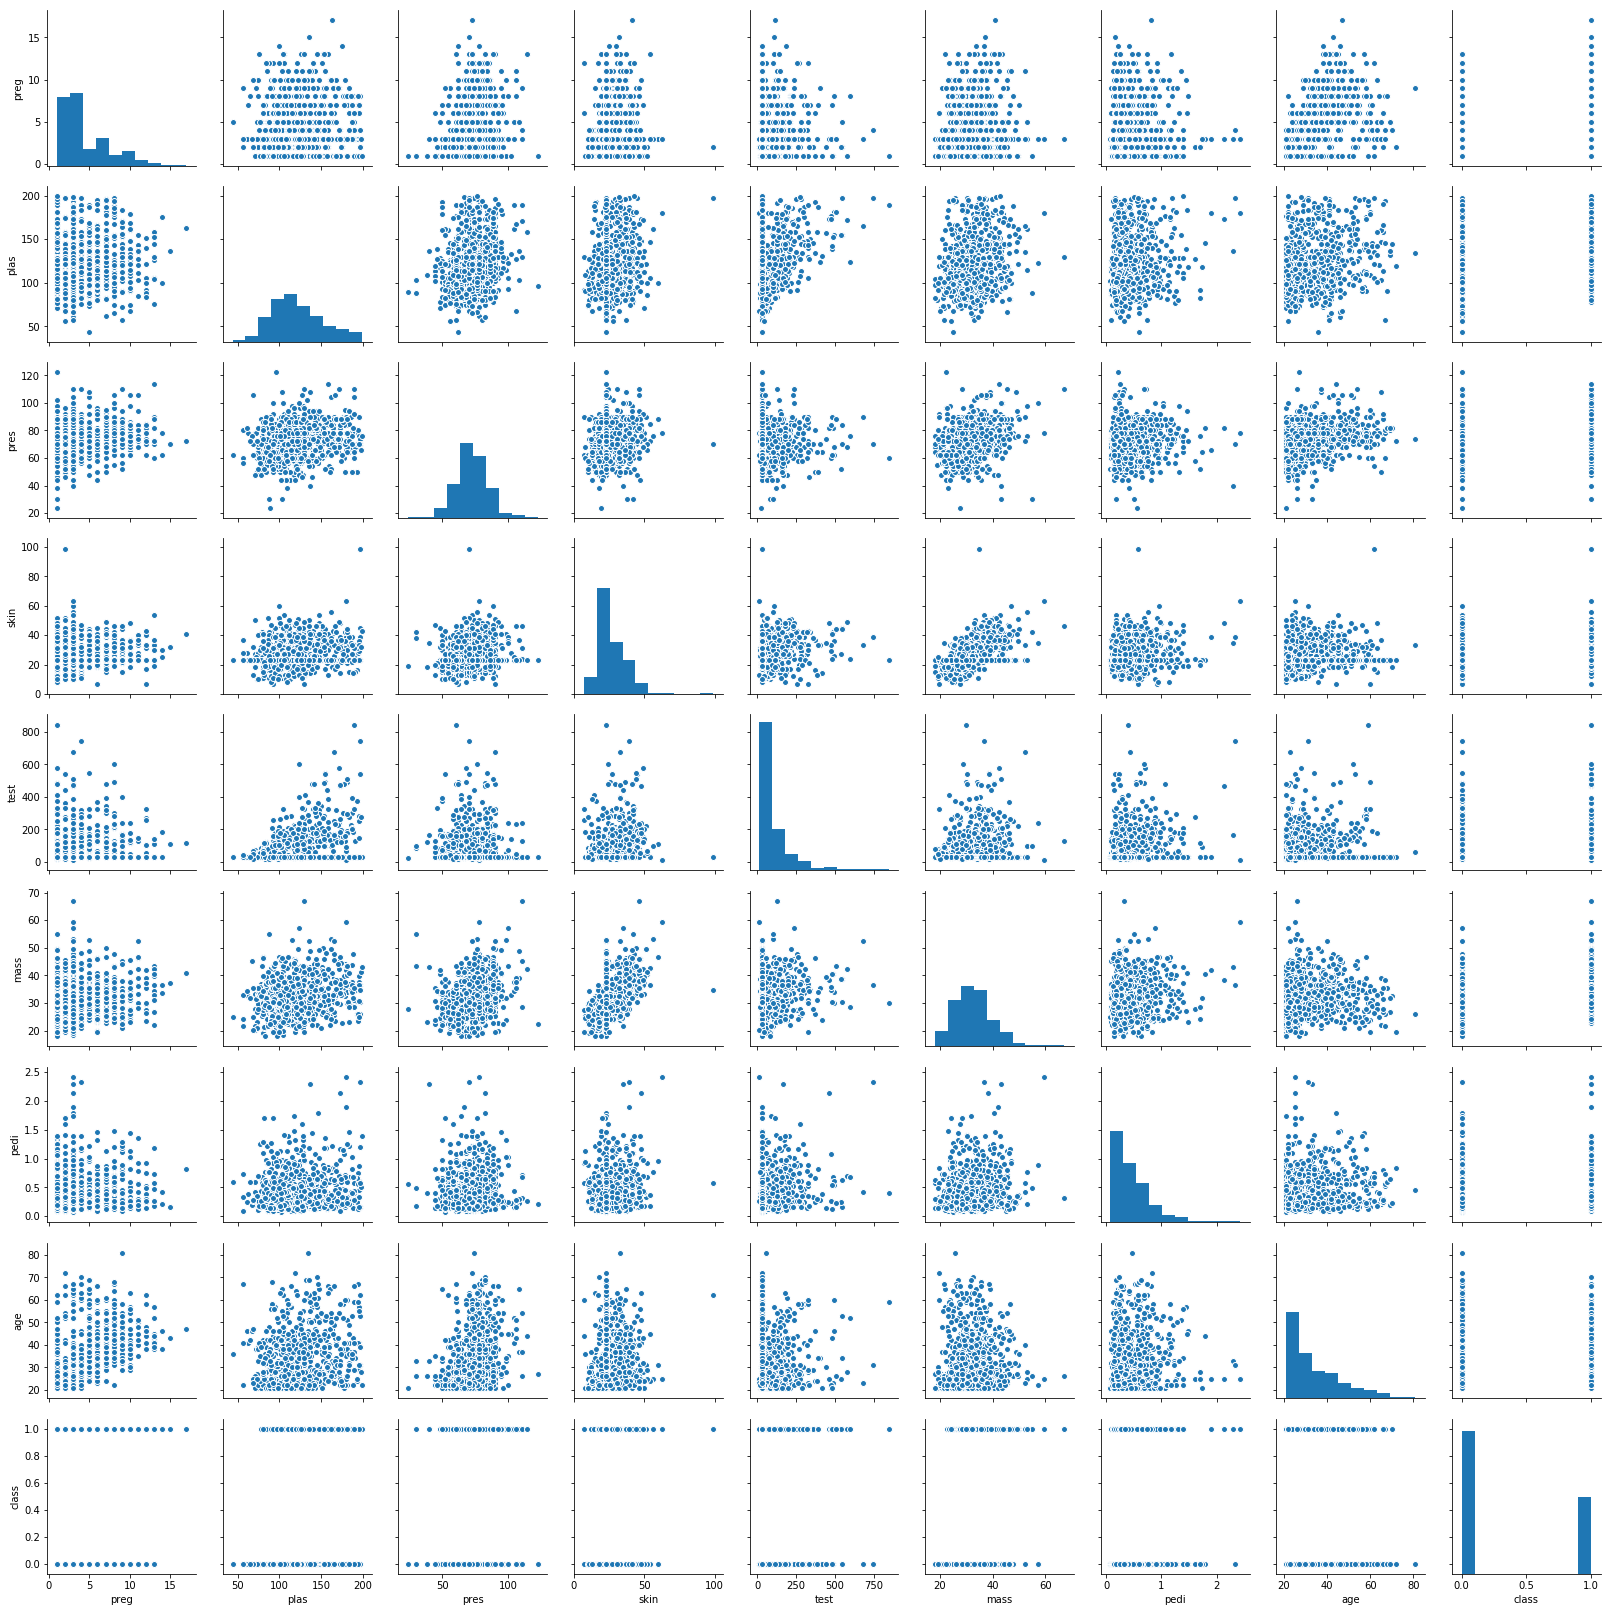

In [25]:
sns.pairplot(pima_df)

In [ ]:
# plasma variable is close to normal distribution with the slight right skewness.Pressure variable too is close to
# Normal distribution with the right skewness.
# Skin thickness is positively correlated to mass.

Using the plot - infer the relationship between different variables

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [26]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

In [27]:
from sklearn.model_selection import train_test_split
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

model=DecisionTreeClassifier(max_depth=4, criterion = 'entropy', random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [34]:
ypred = model.predict(X_test)

In [36]:
acc=metrics.accuracy_score(y_test,ypred)
print(acc)

0.7316017316017316


Print the feature importance of the decision model - Optional

In [37]:
cm = metrics.confusion_matrix(y_test,ypred)
print(cm)

[[106  41]
 [ 21  63]]


In [38]:
cr = metrics.classification_report(y_test,ypred)
print(cr)

             precision    recall  f1-score   support

        0.0       0.83      0.72      0.77       147
        1.0       0.61      0.75      0.67        84

avg / total       0.75      0.73      0.74       231



# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection

In [43]:
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0 )
Rf_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=1,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [44]:
ypred = Rf_model.predict(X_test)

In [45]:
acc=metrics.accuracy_score(y_test,ypred)
print(acc)

0.7532467532467533


In [46]:
cr = metrics.classification_report(y_test,ypred)
print(cr)

             precision    recall  f1-score   support

        0.0       0.80      0.81      0.81       147
        1.0       0.66      0.65      0.66        84

avg / total       0.75      0.75      0.75       231



# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [60]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

In [61]:
sc=StandardScaler()
X=sc.fit_transform(X)

In [62]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=test_size, random_state=seed)

In [63]:
base_LR=LogisticRegression(random_state=2)
boost_LR = AdaBoostClassifier(base_estimator=base_LR,n_estimators=50,random_state=2)

In [64]:
boost_LR.fit(X_train1,y_train1)

AdaBoostClassifier(algorithm='SAMME.R',
          base_estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=2, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False),
          learning_rate=1.0, n_estimators=50, random_state=2)

In [65]:
ypred1=boost_LR.predict(X_test1)
acc=metrics.accuracy_score(y_test1,ypred1)
print(acc)

0.7575757575757576


In [66]:
boost_dt = AdaBoostClassifier(n_estimators=50,random_state=2)
boost_dt.fit(X_train,y_train)
ypred=boost_dt.predict(X_test)
acc=metrics.accuracy_score(y_test,ypred)
print(acc)

0.7272727272727273


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [68]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
base_knn=KNeighborsClassifier(n_neighbors=7,weights='distance')

In [69]:
bag_knn=BaggingClassifier(base_estimator=base_knn,n_estimators=17,random_state=2)

In [70]:
bag_knn.fit(X_train1,y_train1)

BaggingClassifier(base_estimator=KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=7, p=2,
           weights='distance'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=17, n_jobs=1, oob_score=False,
         random_state=2, verbose=0, warm_start=False)

In [71]:
ypred1=bag_knn.predict(X_test1)
acc=metrics.accuracy_score(y_test1,ypred1)
print(acc)

0.7402597402597403


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(n_estimators=50,random_state=2)

In [73]:
gb_model.fit(X_train1, y_train1)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=50,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

In [74]:
y_pred = gb_model.predict(X_test1)

In [76]:
acc=metrics.accuracy_score(y_test1,ypred)
acc

0.7272727272727273

# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.